# Augmentation Testing & Visualisation

Tests and visualises every augmentation class in `fm4tag.augmentations`.

Sections:
1. Imports & synthetic batch helpers
2. Raw-space augmentations: `CutMix`, `ContinuousDilation`, `ContinuousFeatureDilation`, `CategoricalShift`
3. Latent-space augmentation: `Mixup`
4. `AugmentationPipeline` — compose raw + latent stages
5. `MultiViewAugmentation` — N views per forward call
6. `setup_for_object` integration with a real dataset
7. Throughput benchmark

In [1]:
import os, sys, time
sys.path.insert(0, os.path.abspath('../src'))

import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from fm4tag.augmentations import (
    AugmentationPipeline,
    CategoricalShift,
    ContinuousDilation,
    ContinuousFeatureDilation,
    CutMix,
    Mixup,
    MultiViewAugmentation,
)

torch.manual_seed(42)

In [2]:
# ── Synthetic batch helpers ──────────────────────────────────────────────────
N_CON     = 6    # number of continuous features
N_CAT     = 4    # number of categorical features
N_CLASSES = [5, 10, 3, 7]   # classes per categorical feature
BATCH     = 512  # batch size for benchmarks
FEATURE_NAMES = [f"f{i}" for i in range(N_CON)]

def make_raw_batch(B=BATCH, seed=0):
    g = torch.Generator().manual_seed(seed)
    x_categ = torch.stack([
        torch.randint(0, n, (B,), generator=g) for n in N_CLASSES
    ], dim=1)                                       # (B, F_cat)
    x_cont = torch.randn(B, N_CON, generator=g)    # (B, F_con)
    return x_categ, x_cont

def make_embedded(B=BATCH, F=N_CON, dim=32, seed=0):
    g = torch.Generator().manual_seed(seed)
    return torch.randn(B, F, dim, generator=g)

x_categ, x_cont = make_raw_batch()
print("x_categ:", x_categ.shape, x_categ.dtype)
print("x_cont :", x_cont.shape,  x_cont.dtype)

x_categ: torch.Size([512, 4]) torch.int64
x_cont : torch.Size([512, 6]) torch.float32


## 2 · Raw-space augmentations

### 2.1 CutMix

In [3]:
aug = CutMix(lam=0.3)
out_categ, out_cont = aug(x_categ, x_cont)

print("Output shapes:", out_categ.shape, out_cont.shape)
frac_cat = (out_categ != x_categ).float().mean().item()
frac_con = (out_cont  != x_cont ).float().mean().item()
print(f"Categorical — fraction changed: {frac_cat:.3f} (expected ≈ {0.3:.1f})")
print(f"Continuous  — fraction changed: {frac_con:.3f} (expected ≈ {0.3:.1f})")

# Verify output values are drawn from the input pool
assert set(out_categ.flatten().tolist()).issubset(set(x_categ.flatten().tolist()))
print("All output categorical values come from the input pool ✓")

Output shapes: torch.Size([512, 4]) torch.Size([512, 6])
Categorical — fraction changed: 0.239 (expected ≈ 0.3)
Continuous  — fraction changed: 0.303 (expected ≈ 0.3)
All output categorical values come from the input pool ✓


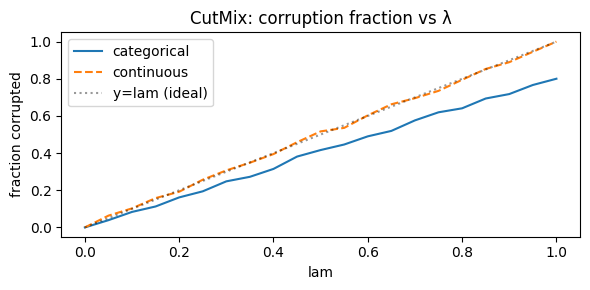

In [4]:
# Visualise corruption fraction as a function of lam
lams = np.linspace(0, 1, 21)
fracs_cat, fracs_con = [], []
for lam in lams:
    aug = CutMix(lam=float(lam))
    oc, on = aug(x_categ, x_cont)
    fracs_cat.append((oc != x_categ).float().mean().item())
    fracs_con.append((on != x_cont ).float().mean().item())

fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(lams, fracs_cat, label="categorical")
ax.plot(lams, fracs_con, label="continuous", linestyle="--")
ax.plot(lams, lams, "k:", alpha=0.4, label="y=lam (ideal)")
ax.set_xlabel("lam"); ax.set_ylabel("fraction corrupted")
ax.set_title("CutMix: corruption fraction vs λ"); ax.legend()
plt.tight_layout(); plt.show()

### 2.2 ContinuousDilation

alpha=0.5: input mean=-0.0214, output mean=-0.0107
  ratio (should be 0.5): -199544.9219
ContinuousDilation ✓


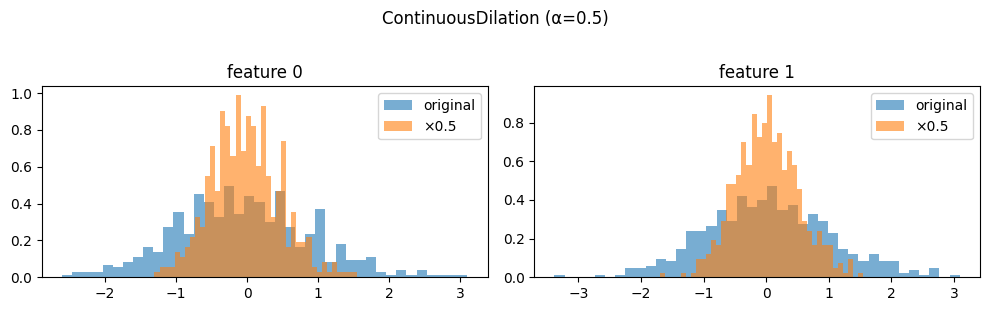

In [5]:
alpha = 0.5
aug = ContinuousDilation(alpha=alpha)
_, out_cont = aug(x_categ, x_cont)

print(f"alpha={alpha}: input mean={x_cont.mean():.4f}, output mean={out_cont.mean():.4f}")
print(f"  ratio (should be {alpha}): {(out_cont / x_cont.clamp(min=1e-6)).mean().item():.4f}")
assert torch.allclose(out_cont, x_cont * alpha)
print("ContinuousDilation ✓")

# Show feature-wise scaling
fig, axes = plt.subplots(1, 2, figsize=(10, 3))
for i, ax in enumerate(axes):
    feature = i
    ax.hist(x_cont[:, feature].numpy(), bins=40, alpha=0.6, label="original", density=True)
    ax.hist(out_cont[:, feature].numpy(), bins=40, alpha=0.6, label=f"×{alpha}", density=True)
    ax.set_title(f"feature {feature}")
    ax.legend()
plt.suptitle(f"ContinuousDilation (α={alpha})", y=1.02)
plt.tight_layout(); plt.show()

### 2.3 ContinuousFeatureDilation  (named features, per-object setup)

In [6]:
TARGET_FEATURES = ["f1", "f3"]   # dilate only these two
alpha = 2.0

aug = ContinuousFeatureDilation(features=TARGET_FEATURES, alpha=alpha)

# setup() resolves feature names to column indices for a specific object
aug.setup(obj_name="tracks", continuous_features=FEATURE_NAMES)
print("Resolved indices:", aug._indices_by_obj["tracks"])

_, out_cont = aug(x_categ, x_cont.clone(), obj_name="tracks")

for i, fname in enumerate(FEATURE_NAMES):
    changed = not torch.allclose(out_cont[:, i], x_cont[:, i])
    expected = fname in TARGET_FEATURES
    mark = "✓" if changed == expected else "✗"
    print(f"  {mark} {fname}: {'dilated' if changed else 'unchanged'} (expected: {'dilated' if expected else 'unchanged'})")

Resolved indices: [1, 3]
  ✓ f0: unchanged (expected: unchanged)
  ✓ f1: dilated (expected: dilated)
  ✓ f2: unchanged (expected: unchanged)
  ✓ f3: dilated (expected: dilated)
  ✓ f4: unchanged (expected: unchanged)
  ✓ f5: unchanged (expected: unchanged)


In [7]:
# Show that a different obj_name uses independent indices
aug.setup(obj_name="jets", continuous_features=list(reversed(FEATURE_NAMES)))
_, out_jets = aug(None, x_cont.clone(), obj_name="jets")

print("\nPer-object index mapping:")
for obj, idxs in aug._indices_by_obj.items():
    feat_at_idx = [FEATURE_NAMES[i] if obj == "tracks" else list(reversed(FEATURE_NAMES))[i] for i in idxs]
    print(f"  {obj}: indices {idxs} → features {feat_at_idx}")


Per-object index mapping:
  tracks: indices [1, 3] → features ['f1', 'f3']
  jets: indices [4, 2] → features ['f1', 'f3']


### 2.4 CategoricalShift

In [8]:
aug = CategoricalShift(p=0.5)
aug.setup(obj_name="tracks", n_classes=N_CLASSES)

out_categ, _ = aug(x_categ.clone(), x_cont, obj_name="tracks")

print("Shift statistics per feature:")
for i, n in enumerate(N_CLASSES):
    deltas  = (out_categ[:, i] - x_categ[:, i]).numpy()
    shifted = (deltas != 0).mean()
    print(f"  feature {i} (n_classes={n}): {shifted*100:.1f}% shifted")
    print(f"    min={out_categ[:, i].min().item()}, max={out_categ[:, i].max().item()} "
          f"(valid range [0, {n-1}])")
    assert out_categ[:, i].min() >= 0
    assert out_categ[:, i].max() <= n - 1
print("All values within valid range ✓")

Shift statistics per feature:
  feature 0 (n_classes=5): 25.2% shifted
    min=0, max=4 (valid range [0, 4])
  feature 1 (n_classes=10): 29.3% shifted
    min=0, max=9 (valid range [0, 9])
  feature 2 (n_classes=3): 24.2% shifted
    min=0, max=2 (valid range [0, 2])
  feature 3 (n_classes=7): 28.1% shifted
    min=0, max=6 (valid range [0, 6])
All values within valid range ✓


In [9]:
# Visualise boundary clamping: pile all values at 0 and n_classes-1,
# shift with p=1.0 and verify the clamp prevents wrap-around.
x_boundary = x_categ.clone()
x_boundary[:, 0] = 0                   # feature 0: all at lower bound
x_boundary[:, 1] = N_CLASSES[1] - 1   # feature 1: all at upper bound

aug_full = CategoricalShift(p=1.0)     # always shift
aug_full.setup(obj_name="tracks", n_classes=N_CLASSES)
out_b, _ = aug_full(x_boundary.clone(), x_cont, obj_name="tracks")

print("Boundary clamping test (p=1.0, all values at boundary):")
print(f"  feature 0 (all=0): min={out_b[:,0].min().item()}, max={out_b[:,0].max().item()} "
      f"(should be [0, 1])")
print(f"  feature 1 (all={N_CLASSES[1]-1}): min={out_b[:,1].min().item()}, max={out_b[:,1].max().item()} "
      f"(should be [{N_CLASSES[1]-2}, {N_CLASSES[1]-1}])")

Boundary clamping test (p=1.0, all values at boundary):
  feature 0 (all=0): min=0, max=1 (should be [0, 1])
  feature 1 (all=9): min=8, max=9 (should be [8, 9])


## 3 · Latent-space augmentation: Mixup

In [10]:
x_emb = torch.randn(BATCH, N_CON, 32)   # (B, F, dim) — embedded batch

aug = Mixup(lam=0.1)
(out_emb,) = aug(x_emb)

print(f"Input  — mean: {x_emb.mean().item():.4f}  std: {x_emb.std().item():.4f}")
print(f"Output — mean: {out_emb.mean().item():.4f}  std: {out_emb.std().item():.4f}")

# lam=1.0 must be identity
(out_id,) = Mixup(lam=1.0)(x_emb)
assert torch.allclose(out_id, x_emb)
print("Mixup(lam=1.0) is identity ✓")

# Two tensors share the same permutation index
x2 = x_emb.clone()
out1, out2 = Mixup(lam=0.5)(x_emb, x2)
assert torch.allclose(out1, out2)
print("Both tensors use the same permutation ✓")

Input  — mean: 0.0009  std: 0.9991
Output — mean: 0.0009  std: 0.9051
Mixup(lam=1.0) is identity ✓
Both tensors use the same permutation ✓


## 4 · AugmentationPipeline

Compose raw and latent stages.  `apply_raw` → embed → `apply_latent`.

In [11]:
pipeline = AugmentationPipeline(
    raw   = [CutMix(lam=0.1), ContinuousDilation(alpha=0.9)],
    latent= [Mixup(lam=0.1)],
)
print("Pipeline:", pipeline)
print("# raw augs:", len(pipeline.raw))
print("# latent augs:", len(pipeline.latent))

x_categ, x_cont = make_raw_batch()

# Raw stage
aug_categ, aug_cont = pipeline.apply_raw(x_categ, x_cont)
print("\nRaw stage — shapes unchanged:",
      aug_categ.shape == x_categ.shape, aug_cont.shape == x_cont.shape)

# Latent stage (simulate embeddings)
x_emb1 = torch.randn(BATCH, N_CON, 32)
x_emb2 = torch.randn(BATCH, N_CAT, 32)
out1, out2 = pipeline.apply_latent(x_emb1, x_emb2)
print("Latent stage — shapes unchanged:", out1.shape == x_emb1.shape)

Pipeline: AugmentationPipeline(
  (raw): ModuleList(
    (0): CutMix()
    (1): ContinuousDilation()
  )
  (latent): ModuleList(
    (0): Mixup()
  )
)
# raw augs: 2
# latent augs: 1

Raw stage — shapes unchanged: True True
Latent stage — shapes unchanged: True


In [12]:
# Test obj_name forwarding through the pipeline
aug_fd = ContinuousFeatureDilation(features=["f0", "f2"], alpha=3.0)
aug_fd.setup(obj_name="tracks", continuous_features=FEATURE_NAMES)

pipeline_obj = AugmentationPipeline(raw=[CutMix(lam=0.0), aug_fd])

_, out_tracks = pipeline_obj.apply_raw(x_categ, x_cont.clone(), obj_name="tracks")
_, out_jets   = pipeline_obj.apply_raw(None,    x_cont.clone(), obj_name="jets")   # not set up → noop

ratio_tracks = (out_tracks[:, 0] / x_cont[:, 0]).mean().item()
ratio_jets   = (out_jets[:, 0]   / x_cont[:, 0]).mean().item()
print(f"tracks f0 ratio (should be 3.0): {ratio_tracks:.3f}")
print(f"jets   f0 ratio (should be 1.0): {ratio_jets:.3f}")

tracks f0 ratio (should be 3.0): 3.000
jets   f0 ratio (should be 1.0): 1.000


## 5 · MultiViewAugmentation — N views per forward call

In [13]:
multi_aug = MultiViewAugmentation([
    AugmentationPipeline(raw=[CutMix(lam=0.1)],              latent=[Mixup(lam=0.1)]),
    AugmentationPipeline(raw=[ContinuousDilation(alpha=0.9)], latent=[]),
    AugmentationPipeline(raw=[CutMix(lam=0.2), ContinuousDilation(alpha=1.1)], latent=[]),
])

print(f"n_views: {multi_aug.n_views}")

x_categ, x_cont = make_raw_batch()
views = multi_aug(x_categ, x_cont)

print(f"Number of views returned: {len(views)}")
for i, (vc, vn) in enumerate(views):
    print(f"  view {i}: categ={vc.shape}  cont={vn.shape}")

n_views: 3
Number of views returned: 3
  view 0: categ=torch.Size([512, 4])  cont=torch.Size([512, 6])
  view 1: categ=torch.Size([512, 4])  cont=torch.Size([512, 6])
  view 2: categ=torch.Size([512, 4])  cont=torch.Size([512, 6])


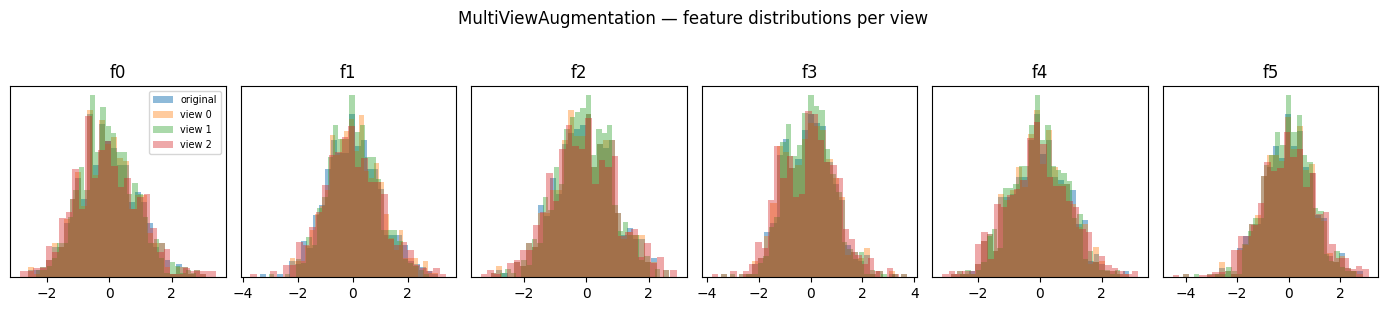

In [ ]:
# Visualise continuous feature distributions across views
fig, axes = plt.subplots(1, N_CON, figsize=(14, 3))
for f, ax in enumerate(axes):
    ax.hist(x_cont[:, f].numpy(), bins=30, alpha=0.5, density=True, label="original")
    for i, (_, vn) in enumerate(views):
        ax.hist(vn[:, f].numpy(), bins=30, alpha=0.4, density=True, label=f"view {i}")
    ax.set_title(f"f{f}"); ax.set_yticks([])
axes[0].legend(fontsize=7)
plt.suptitle("MultiViewAugmentation — feature distributions per view", y=1.02)
plt.tight_layout(); plt.show()

## 6 · `setup_for_dataset` integration with a real dataset

Loads the actual dataset and resolves feature names to column indices for
object-aware augmentations.

In [15]:
from hydra import compose, initialize_config_dir
from hydra.core.global_hydra import GlobalHydra
from omegaconf import OmegaConf
from fm4tag.datasets import DatasetCatCon

CONFIG_NAME = "atlas_tracks_saint"

GlobalHydra.instance().clear()
with initialize_config_dir(config_dir=os.path.abspath('../configs'), version_base=None):
    cfg = compose(config_name=CONFIG_NAME)

norm_dict  = OmegaConf.to_container(OmegaConf.load(cfg.norm_dict),  resolve=True) if cfg.get("norm_dict")  else None
class_dict = OmegaConf.to_container(OmegaConf.load(cfg.class_dict), resolve=True) if cfg.get("class_dict") else None

dataset = DatasetCatCon(
    file_path=cfg.pretrain_file,
    variables=cfg.variables,
    global_object=cfg.global_object,
    constituent_objects=list(cfg.constituent_objects),
    norm_dict=norm_dict,
    class_dict=class_dict,
)


DatasetCatCon: /storage3/DSIP/rriva/datasets/transforming-jet-flavor/data_parallel_preprocess_251112_112137/pretrain/output/pp_output_pretrain.h5
  samples : 500000


In [16]:
from fm4tag.augmentations import ContinuousFeatureDilation, CategoricalShift
from fm4tag.utils.builders import build_aug_module

# Build MultiViewAugmentation from config (augmentation group is cutmix_mixup by default)
aug_module = build_aug_module(cfg, dataset=dataset)
print(f"n_views: {aug_module.n_views}")
if aug_module.n_views == 0:
    print("(none.yaml or empty views list — switch to multi_view to see more)")

# Or build manually with object-aware augmentations:
aug_manual = MultiViewAugmentation([
    AugmentationPipeline(raw=[CutMix(lam=0.1)]),
    AugmentationPipeline(raw=[
        ContinuousFeatureDilation(features=["d0", "z0SinTheta"], alpha=0.8),
        CategoricalShift(p=0.3),
    ]),
])
aug_manual.setup_for_dataset(dataset)

# Check resolved state for tracks
aug_fd = aug_manual.pipelines[1].raw[0]
print("\nContinuousFeatureDilation resolved indices (tracks):")
for obj, idxs in aug_fd._indices_by_obj.items():
    print(f"  {obj}: {idxs}")

n_views: 1

ContinuousFeatureDilation resolved indices (tracks):
  jets: []
  tracks: [0, 1]


In [17]:
# Run on a real batch
from fm4tag.datasets import cat_con_collate_fn
from torch.utils.data import DataLoader

loader = DataLoader(dataset, batch_size=256, shuffle=True, num_workers=0,
                    collate_fn=cat_con_collate_fn)
batch = next(iter(loader))

x_categ_tracks = batch["constituents"]["tracks"]["categorical"]  # (B, N, F_cat)
x_cont_tracks  = batch["constituents"]["tracks"]["continuous"]   # (B, N, F_con)

views = aug_manual(x_categ_tracks, x_cont_tracks, obj_name="tracks")
print(f"\nReal batch — {len(views)} views:")
for i, (vc, vn) in enumerate(views):
    print(f"  view {i}: categ={vc.shape}, cont={vn.shape}")


Real batch — 2 views:
  view 0: categ=torch.Size([256, 40, 9]), cont=torch.Size([256, 40, 10])
  view 1: categ=torch.Size([256, 40, 9]), cont=torch.Size([256, 40, 10])


## 6.2 · Real-data distributions — before vs after augmentation

Each plot overlays the original feature distribution (from real pretrain data) with
the distribution after applying different augmentations.  Track tensors are
flattened over the N-tracks dimension and filtered by the `valid` mask.

In [ ]:
# Feature name lists from the loaded config
con_names_tracks = list(cfg.variables.tracks.inputs.continuous)
cat_names_tracks = list(cfg.variables.tracks.inputs.categorical)
n_classes_tracks = [len(v) for v in cfg.variables.tracks.inputs.cat_classes.values()]
jet_feat_names   = list(cfg.variables.jets.inputs)

# Flatten (B, N, F) track tensors and remove padding with the valid mask
x_cont_t  = batch["constituents"]["tracks"]["continuous"]   # (B, N, F_con)
x_categ_t = batch["constituents"]["tracks"]["categorical"]  # (B, N, F_cat)
valid      = batch["constituents"]["tracks"]["valid"]        # (B, N) bool

B, N, F_con = x_cont_t.shape
flat_cont  = x_cont_t.reshape(-1, F_con)[valid.reshape(-1)]
flat_categ = x_categ_t.reshape(-1, x_categ_t.shape[-1])[valid.reshape(-1)]

print(f"Jet features  ({len(jet_feat_names)}): {jet_feat_names}")
print(f"Track cont    ({len(con_names_tracks)}): {con_names_tracks}")
print(f"Track cat     ({len(cat_names_tracks)}): {cat_names_tracks}")
print(f"\nValid tracks: {flat_cont.shape[0]:,} / {B*N:,}  ({100*flat_cont.shape[0]/(B*N):.1f}%)")
print(f"batch['global'] shape: {batch['global'].shape}")

In [ ]:
aug_dil_all  = ContinuousDilation(alpha=0.5)
aug_dil_deta = ContinuousFeatureDilation(features=["deta"], alpha=3.0)
aug_dil_deta.setup(obj_name="tracks", continuous_features=con_names_tracks)
aug_cutmix_t = CutMix(lam=0.3)

_, out_dil_all  = aug_dil_all(flat_categ, flat_cont)
_, out_dil_deta = aug_dil_deta(flat_categ, flat_cont.clone(), obj_name="tracks")
_, out_cutmix_t = aug_cutmix_t(flat_categ, flat_cont)

TRACK_FEATS = ["deta", "d0"]
fig, axes = plt.subplots(1, len(TRACK_FEATS), figsize=(12, 4))
for ax, feat in zip(axes, TRACK_FEATS):
    fidx = con_names_tracks.index(feat)
    orig = flat_cont[:, fidx].numpy()
    lim  = float(np.percentile(np.abs(orig), 95)) * 2
    bins = np.linspace(-lim, lim, 60)
    ax.hist(orig,                          bins=bins, alpha=0.55, density=True, label="original")
    ax.hist(out_dil_all[:, fidx].numpy(),  bins=bins, alpha=0.55, density=True, label="ContinuousDilation(α=0.5)")
    ax.hist(out_dil_deta[:, fidx].numpy(), bins=bins, alpha=0.55, density=True, label="ContinuousFeatureDilation(deta, α=3.0)")
    ax.hist(out_cutmix_t[:, fidx].numpy(), bins=bins, alpha=0.40, density=True, label="CutMix(lam=0.3)")
    ax.set_xlabel(f"{feat} (normalised)"); ax.set_ylabel("density"); ax.set_title(f"Track {feat}")
axes[0].legend(fontsize=8)
plt.suptitle("Track continuous features — before vs after augmentation", y=1.02)
plt.tight_layout(); plt.show()

In [ ]:
x_global = batch["global"]   # (B, F_g)  normalised [pt_btagJes, eta_btagJes]

aug_dil_jets    = ContinuousDilation(alpha=0.5)
aug_cutmix_jets = CutMix(lam=0.3)

_, out_dil_jets    = aug_dil_jets(None, x_global)
_, out_cutmix_jets = aug_cutmix_jets(None, x_global)

fig, axes = plt.subplots(1, len(jet_feat_names), figsize=(12, 4))
for ax, feat in zip(axes, jet_feat_names):
    fidx = jet_feat_names.index(feat)
    orig = x_global[:, fidx].numpy()
    lim  = float(np.percentile(np.abs(orig), 98)) * 1.5
    bins = np.linspace(-lim, lim, 60)
    ax.hist(orig,                             bins=bins, alpha=0.55, density=True, label="original")
    ax.hist(out_dil_jets[:, fidx].numpy(),    bins=bins, alpha=0.55, density=True, label="ContinuousDilation(α=0.5)")
    ax.hist(out_cutmix_jets[:, fidx].numpy(), bins=bins, alpha=0.40, density=True, label="CutMix(lam=0.3)")
    ax.set_xlabel(f"{feat} (normalised)"); ax.set_ylabel("density"); ax.set_title(f"Jet {feat}")
axes[0].legend(fontsize=8)
plt.suptitle("Jet features — before vs after augmentation", y=1.02)
plt.tight_layout(); plt.show()

In [ ]:
aug_shift = CategoricalShift(p=0.5)
aug_shift.setup(obj_name="tracks", n_classes=n_classes_tracks)
out_shifted, _ = aug_shift(flat_categ.clone(), flat_cont, obj_name="tracks")

cat_feats_plot = ["numberOfPixelHits", "numberOfSCTHits"]
fig, axes = plt.subplots(1, len(cat_feats_plot), figsize=(14, 4))
for ax, feat in zip(axes, cat_feats_plot):
    cidx  = cat_names_tracks.index(feat)
    n_cls = n_classes_tracks[cidx]
    bins  = np.arange(-0.5, n_cls + 0.5)
    ax.hist(flat_categ[:, cidx].numpy(),  bins=bins, alpha=0.6, density=True,
            label="original", color="steelblue")
    ax.hist(out_shifted[:, cidx].numpy(), bins=bins, alpha=0.6, density=True,
            label="CategoricalShift(p=0.5)", color="darkorange")
    ax.set_xlabel(f"{feat} (class index)"); ax.set_ylabel("density")
    ax.set_title(feat); ax.legend()
plt.suptitle("Track categorical features — before vs after CategoricalShift", y=1.02)
plt.tight_layout(); plt.show()

## 7 · Augmentation throughput benchmark

In [18]:
BENCH_B = 2048
BENCH_N = 100

def bench_aug(aug_or_fn, label, B=BENCH_B, n_reps=BENCH_N):
    x_c, x_n = make_raw_batch(B=B)
    # warmup
    for _ in range(5):
        aug_or_fn(x_c, x_n)
    t0 = time.perf_counter()
    for _ in range(n_reps):
        aug_or_fn(x_c, x_n)
    elapsed = time.perf_counter() - t0
    throughput = B * n_reps / elapsed
    print(f"  {label:<40} {throughput:>12,.0f} samples/s")

print(f"Throughput ({BENCH_B}-sample batch, {BENCH_N} reps)\n")

# Single augmentations
bench_aug(CutMix(lam=0.1),           "CutMix(lam=0.1)")
bench_aug(ContinuousDilation(0.9),   "ContinuousDilation(alpha=0.9)")

aug_fd = ContinuousFeatureDilation(features=["f0", "f2", "f4"], alpha=0.8)
aug_fd.setup(obj_name="", continuous_features=FEATURE_NAMES)
bench_aug(lambda c, n: aug_fd(c, n, obj_name=""), "ContinuousFeatureDilation(3 features)")

aug_cs = CategoricalShift(p=0.5)
aug_cs.setup(obj_name="", n_classes=N_CLASSES)
bench_aug(lambda c, n: aug_cs(c, n, obj_name=""), "CategoricalShift(p=0.5)")

# Multi-view pipeline
mv = MultiViewAugmentation([
    AugmentationPipeline(raw=[CutMix(lam=0.1)]),
    AugmentationPipeline(raw=[ContinuousDilation(0.9)]),
    AugmentationPipeline(raw=[CutMix(lam=0.1), ContinuousDilation(0.9)]),
])
bench_aug(lambda c, n: mv(c, n), "MultiViewAugmentation(3 views)")

Throughput (2048-sample batch, 100 reps)

  CutMix(lam=0.1)                             5,568,016 samples/s
  ContinuousDilation(alpha=0.9)             379,896,494 samples/s
  ContinuousFeatureDilation(3 features)      11,967,487 samples/s
  CategoricalShift(p=0.5)                    13,846,036 samples/s
  MultiViewAugmentation(3 views)              2,988,426 samples/s
